# 🔥 FireGuard — Real-Time Fire & Smoke Detection

**Broadcast-grade fire & smoke intelligence on video — three generations of YOLO, one pipeline.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ParsaVictor/fireguard/blob/main/FireGuard.ipynb)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](LICENSE)
[![Python 3.10+](https://img.shields.io/badge/python-3.10%2B-blue.svg)]()
[![ultralytics](https://img.shields.io/badge/YOLO-ultralytics-8A2BE2.svg)]()

### ✨ What you get
| Capability | How |
|---|---|
| 🎯 **Accurate detection** | Swappable pretrained models: **YOLOv8n / YOLO11s / YOLO26s** (no training needed) |
| 🟥 **Region marking** | Fire area is filled, bracketed, labelled and wrapped in a dashed **safety zone** |
| 🚦 **Hazard state machine** | `SAFE → CAUTION → WARNING → DANGER → CRITICAL` with temporal confirmation (no flicker, no false alarms) |
| 📢 **Smart alerts** | Anti-spam cooldown, `events.csv` timeline, evidence snapshots on every escalation |
| ⚡ **Fast & light** | Per-class confidence, frame-skip, FP16 on GPU, CPU-friendly by default |
| 🧩 **Profiles** | `standard` / `fire-only` (government mode) / `early-smoke` (earliest warning) |

### 🇮🇷 فارسی
سیستم هوشمند تشخیص آتش و دود روی ویدیو — سه نسل مدل YOLO به‌صورت قابل تعویض، مشخص‌سازی دقیق محدوده آتش، ماشین وضعیت خطر با تأیید زمانی، هشدارهای هوشمند و خروجی ویدیویی حرفه‌ای. کافیست ویدیو را معرفی کنید و سلول‌ها را اجرا کنید.

---


## 1 · Setup
Installs everything (safe to re-run — skips what's already present). In **Colab**, enable GPU: `Runtime → Change runtime type → T4 GPU`.


In [1]:
%pip install -q ultralytics huggingface_hub matplotlib pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip


## 2 · Imports & device


In [2]:
# FireGuard — real-time fire & smoke intelligence on video
import os
import csv
import time
import math
import shutil
import warnings
import subprocess
from dataclasses import dataclass, field
from collections import deque

import cv2
import numpy as np
import torch

warnings.filterwarnings("ignore")


## 3 · Configuration — *the one cell you edit*

| Knob | Meaning |
|---|---|
| `model` | `yolov8n` (fastest, 3.0M params) · `yolo11s` (balanced) · `yolo26s` (newest, most stable) · or a path to **any** custom `.pt` |
| `profile` | `standard` · `fire-only` (ignore smoke — e.g. government/open-terrain) · `early-smoke` (lowest smoke threshold) |
| `conf_fire` / `conf_smoke` | `None` → taken from the profile; set a number to override |
| `frame_skip` | run inference every Nth frame (2 ≈ 2× faster, boxes are reused between) |
| `confirm_window` / `confirm_hits` / `clear_frames` | temporal hysteresis — how stubborn the alarms are |


In [3]:
CONFIG = {
    # --- model ---
    "model": "yolo26s",          # yolov8n | yolo11s | yolo26s | path/to/custom.pt
    "imgsz": 640,
    "iou": 0.45,

    # --- operating profile (presets) ---
    # standard    : fire + smoke, balanced thresholds (default)
    # fire-only   : ignore smoke entirely (government / open-terrain mode)
    # early-smoke : ultra-sensitive smoke -> earliest possible warning
    "profile": "standard",

    # --- per-class confidence (overridden by profile unless set here) ---
    "conf_fire": None,           # None -> take from profile
    "conf_smoke": None,

    # --- speed ---
    "frame_skip": 1,             # run inference every Nth frame (1 = every frame)
    "start_frame": 0,            # begin analysis at this frame (skip intro)
    "max_frames": None,          # stop early (None = whole video)

    # --- robustness (temporal confirmation, kills flicker/false alarms) ---
    "confirm_window": 5,         # look at the last N frames
    "confirm_hits": 2,           # need >= K hits in that window to CONFIRM a class
    "clear_frames": 8,           # hold the alarm this many misses before clearing

    # --- alerts ---
    "alert_cooldown_s": 4.0,     # repeat-alarm interval while hazard is active

    # --- output ---
    "output_dir": "outputs",
    "snapshot": True,            # save evidence PNG on every escalation
    "display_samples": 6,        # annotated frames returned for inline display
}

PROFILES = {
    "standard":   {"fire": True, "smoke": True,  "conf_fire": 0.30, "conf_smoke": 0.25},
    "fire-only":  {"fire": True, "smoke": False, "conf_fire": 0.30, "conf_smoke": 0.25},
    "early-smoke": {"fire": True, "smoke": True, "conf_fire": 0.35, "conf_smoke": 0.15},
}


## 4 · Model zoo — three YOLO generations
All weights are **verified, public Hugging Face checkpoints** (downloaded once, cached in `models/`).


In [4]:
MODEL_REGISTRY = {
    "yolov8n": {
        "repo": "rabahdev/fire-smoke-yolov8n",
        "file": "best.pt",
        "params": "3.0M",
        "note": "Fastest — edge devices / weak CPUs",
    },
    "yolo11s": {
        "repo": "leeyunjai/yolo11-firedetect",
        "file": "firedetect-11s.pt",
        "params": "9.4M",
        "note": "Balanced accuracy vs speed",
    },
    "yolo26s": {
        "repo": "SalahALHaismawi/yolov26-fire-detection",
        "file": "best.pt",
        "params": "9.9M",
        "note": "Newest generation — best accuracy",
    },
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def load_model(key: str, cache_dir: str = "models"):
    """Load a model from the registry (cached locally) or a custom .pt path."""
    from ultralytics import YOLO

    if key in MODEL_REGISTRY:
        spec = MODEL_REGISTRY[key]
        local = os.path.join(cache_dir, f"{key}.pt")
        if not os.path.exists(local):
            os.makedirs(cache_dir, exist_ok=True)
            from huggingface_hub import hf_hub_download
            print(f"⬇️  Downloading {key} ({spec['repo']}) ...")
            path = hf_hub_download(repo_id=spec["repo"], filename=spec["file"])
            shutil.copy(path, local)
        weights = local
    elif os.path.isfile(key):
        weights = key
    else:
        raise FileNotFoundError(
            f"Unknown model '{key}'. Choose one of {list(MODEL_REGISTRY)} or pass a .pt path."
        )

    model = YOLO(weights)
    print(f"✅ Loaded '{os.path.basename(weights)}'  |  classes: {list(model.names.values())}  |  device: {DEVICE}")
    return model


## 5 · Detection layer
Normalises every dataset's label spelling (`Fire`, `fire`, `FLAME`…) and applies per-class confidence + minimum-box-size filtering.


In [5]:
def normalize_class(name: str):
    """Map any dataset's label spelling to 'fire' / 'smoke' (or ignore)."""
    n = name.lower()
    if "fire" in n or "flame" in n:
        return "fire"
    if "smoke" in n:
        return "smoke"
    return None  # e.g. yolo26s extra class 'other'


@dataclass
class Detection:
    cls: str
    conf: float
    x1: int
    y1: int
    x2: int
    y2: int

    @property
    def centroid(self):
        return (self.x1 + self.x2) // 2, (self.y1 + self.y2) // 2

    @property
    def area(self):
        return max(0, self.x2 - self.x1) * max(0, self.y2 - self.y1)


def detect(model, frame, cfg) -> list:
    """Run inference + per-class confidence & size filtering."""
    conf_fire = cfg["_conf_fire"]
    conf_smoke = cfg["_conf_smoke"]
    min_area = 0.0008 * frame.shape[0] * frame.shape[1]

    results = model.predict(
        source=frame,
        imgsz=cfg["imgsz"],
        conf=min(conf_fire, conf_smoke),
        iou=cfg["iou"],
        device=DEVICE,
        half=(DEVICE == "cuda"),
        verbose=False,
    )

    dets = []
    for box in results[0].boxes:
        cls = normalize_class(model.names[int(box.cls[0])])
        if cls is None or not cfg["_use"].get(cls, False):
            continue
        conf = float(box.conf[0])
        if conf < (conf_fire if cls == "fire" else conf_smoke):
            continue
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        d = Detection(cls, conf, x1, y1, x2, y2)
        if d.area < min_area:
            continue
        dets.append(d)
    return dets


## 6 · Hazard engine — state machine with hysteresis
A fire alarm must be **confirmed over several frames** (no one-frame false positives) and **survives brief dropout** (no flicker).


In [6]:
HAZARD_STATES = {
    "SAFE":     {"color": (89, 199, 52),   "label": "SAFE"},
    "CAUTION":  {"color": (10, 214, 255),  "label": "CAUTION"},
    "WARNING":  {"color": (10, 159, 255),  "label": "WARNING — SMOKE"},
    "DANGER":   {"color": (58, 69, 255),   "label": "DANGER — FIRE"},
    "CRITICAL": {"color": (85, 45, 255),   "label": "CRITICAL — FIRE + SMOKE"},
}
_ORDER = ["SAFE", "CAUTION", "WARNING", "DANGER", "CRITICAL"]


class HazardEngine:
    """Confirms classes over time so one flickering frame can't raise an alarm,
    and one missed frame can't silently clear one (hysteresis)."""

    def __init__(self, cfg):
        self.w = cfg["confirm_window"]
        self.k = cfg["confirm_hits"]
        self.clear = cfg.get("clear_frames", 8)
        self.hist = {"fire": deque(maxlen=self.w), "smoke": deque(maxlen=self.w)}
        self.miss = {"fire": self.clear, "smoke": self.clear}
        self.active = {"fire": False, "smoke": False}
        self.state = "SAFE"
        self.cooldown_s = cfg["alert_cooldown_s"]
        self._last_alarm_t = 0.0

    def update(self, dets) -> dict:
        present = {"fire": any(d.cls == "fire" for d in dets),
                   "smoke": any(d.cls == "smoke" for d in dets)}
        for c, hit in present.items():
            self.hist[c].append(hit)
            if hit:
                self.miss[c] = 0
            else:
                self.miss[c] += 1
            if not self.active[c] and sum(self.hist[c]) >= self.k:
                self.active[c] = True                       # confirm
            elif self.active[c] and self.miss[c] >= self.clear:
                self.active[c] = False                      # clear (hysteresis)

        confirmed = dict(self.active)
        any_seen = any(present.values())

        if confirmed["fire"] and confirmed["smoke"]:
            state = "CRITICAL"
        elif confirmed["fire"]:
            state = "DANGER"
        elif confirmed["smoke"]:
            state = "WARNING"
        elif any_seen:
            state = "CAUTION"
        else:
            state = "SAFE"

        changed = state != self.state
        escalated = _ORDER.index(state) > _ORDER.index(self.state)
        self.state = state

        now = time.time()
        repeat = (
            state in ("DANGER", "CRITICAL")
            and not changed
            and now - self._last_alarm_t >= self.cooldown_s
        )
        if changed or repeat:
            self._last_alarm_t = now

        return {
            "state": state,
            "changed": changed,
            "escalated": escalated,
            "confirmed_fire": confirmed["fire"],
            "confirmed_smoke": confirmed["smoke"],
        }


## 7 · Overlay renderer
Corner brackets · label chips · translucent fire-region fill · dashed safety zone · HUD · pulsing border.


In [7]:
FIRE_COLOR = (48, 59, 255)      # #FF3B30
SMOKE_COLOR = (0, 196, 255)     # #FFC400


def _blend(img, x1, y1, x2, y2, color, alpha):
    """Alpha-blend a solid color over a rectangular region, in place."""
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
    if x2 <= x1 or y2 <= y1:
        return
    roi = img[y1:y2, x1:x2]
    img[y1:y2, x1:x2] = (roi * (1 - alpha) + np.array(color, dtype=np.float32) * alpha).astype(np.uint8)


def _chip(img, text, x, y, color, scale=0.55, thick=2, pad=6, text_color=(255, 255, 255)):
    """Text on a filled label chip; returns bottom-left of the chip."""
    (tw, th), bl = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, thick)
    h = th + 2 * pad
    y0 = y - h if y - h >= 0 else y          # flip below if clipped at top
    _blend(img, x, y0, x + tw + 2 * pad, y0 + h, color, 0.85)
    cv2.putText(img, text, (x + pad, y0 + h - pad - bl + 1),
                cv2.FONT_HERSHEY_SIMPLEX, scale, text_color, thick, cv2.LINE_AA)
    return y0


def _brackets(img, x1, y1, x2, y2, color, thick=3):
    """Professional corner brackets instead of a full rectangle."""
    l = int(np.clip(0.22 * min(x2 - x1, y2 - y1), 10, 36))
    for (px, py, dx, dy) in [(x1, y1, 1, 1), (x2, y1, -1, 1), (x1, y2, 1, -1), (x2, y2, -1, -1)]:
        cv2.line(img, (px, py), (px + dx * l, py), color, thick, cv2.LINE_AA)
        cv2.line(img, (px, py), (px, py + dy * l), color, thick, cv2.LINE_AA)


def _dashed_circle(img, center, radius, color, n_seg=20, thick=2, alpha=0.0):
    step = int(360 / n_seg)
    overlay = img.copy() if alpha else img
    for a in range(0, 360, 2 * step):
        cv2.ellipse(overlay, center, (radius, radius), 0, a, a + step, color, thick, cv2.LINE_AA)
    if alpha:
        cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)


def draw_overlay(frame, dets, eng_info, stats, t_idx) -> np.ndarray:
    """All visual annotation: region highlight, brackets, danger zone, HUD, pulse."""
    img = frame.copy()
    H, W = img.shape[:2]
    state = eng_info["state"]

    # --- per-detection annotation ---
    for d in dets:
        color = FIRE_COLOR if d.cls == "fire" else SMOKE_COLOR
        if d.cls == "fire":
            _blend(img, d.x1, d.y1, d.x2, d.y2, color, 0.14)     # highlighted fire region
        _brackets(img, d.x1, d.y1, d.x2, d.y2, color)
        icon = "FIRE" if d.cls == "fire" else "SMOKE"
        _chip(img, f"{icon} {d.conf * 100:.1f}%", d.x1, d.y1 - 6, color)

        if d.cls == "fire":                                       # safety zone around the fire
            cx, cy = d.centroid
            r = int(0.65 * max(d.x2 - d.x1, d.y2 - d.y1))
            _dashed_circle(img, (cx, cy), r, FIRE_COLOR, thick=2, alpha=0.45)
            cv2.line(img, (cx - 10, cy), (cx + 10, cy), FIRE_COLOR, 2, cv2.LINE_AA)
            cv2.line(img, (cx, cy - 10), (cx, cy + 10), FIRE_COLOR, 2, cv2.LINE_AA)

    # --- pulsing border in critical states (drawn before HUD so it stays readable) ---
    sc = HAZARD_STATES[state]["color"]
    if state in ("DANGER", "CRITICAL"):
        a = 0.30 + 0.22 * math.sin(2 * math.pi * t_idx / 15.0)
        b = 8 if state == "CRITICAL" else 5
        _blend(img, 0, 0, W, b, sc, a)
        _blend(img, 0, H - b, W, H, sc, a)
        _blend(img, 0, 0, b, H, sc, a)
        _blend(img, W - b, 0, W, H, sc, a)

    # --- HUD (top-left, always on top) ---
    hud1 = f"FireGuard  |  {HAZARD_STATES[state]['label']}"
    hud2 = (f"{stats['fps']:.1f} FPS  |  fire:{stats['n_fire']}  smoke:{stats['n_smoke']}"
            f"  |  frame {stats['frame']}")
    scale = 0.55 if H >= 480 else 0.45
    y0 = _chip(img, hud1, 10, 12, sc, scale=scale)
    _chip(img, hud2, 10, y0 + 4, (20, 20, 20), scale=scale * 0.92, thick=1,
          text_color=(240, 240, 240), pad=5)
    return img


## 8 · Video pipeline
Read → detect → confirm → annotate → write. Produces the annotated MP4 (H.264), `events.csv` and escalation snapshots.


In [8]:
def _resolve_profile(cfg):
    prof = PROFILES[cfg["profile"]]
    cfg["_use"] = {"fire": prof["fire"], "smoke": prof["smoke"]}
    cfg["_conf_fire"] = cfg["conf_fire"] if cfg["conf_fire"] is not None else prof["conf_fire"]
    cfg["_conf_smoke"] = cfg["conf_smoke"] if cfg["conf_smoke"] is not None else prof["conf_smoke"]
    return cfg


def process_video(model, cfg, src, out_name="result.mp4", max_frames=None, quiet=False):
    """Main loop: read -> detect -> confirm -> annotate -> write + log events."""
    cfg = _resolve_profile(dict(cfg))
    max_frames = max_frames or cfg["max_frames"]

    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {src}")
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    os.makedirs(cfg["output_dir"], exist_ok=True)
    snap_dir = os.path.join(cfg["output_dir"], "snapshots")
    os.makedirs(snap_dir, exist_ok=True)
    temp = os.path.join(cfg["output_dir"], "_temp.mp4")
    final = os.path.join(cfg["output_dir"], out_name)
    writer = cv2.VideoWriter(temp, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

    eng = HazardEngine(cfg)
    events, samples = [], []
    for _ in range(cfg.get("start_frame", 0)):   # fast-forward without decoding
        if not cap.grab():
            break
    n_total = min(total - cfg.get("start_frame", 0), max_frames) if max_frames else total - cfg.get("start_frame", 0)
    sample_at = set(np.linspace(0, max(n_total - 1, 1), cfg["display_samples"]).astype(int)) if n_total > 1 else {0}

    stats = {"fps": 0.0, "n_fire": 0, "n_smoke": 0, "frame": 0}
    t0, frames_done, det_frames, det_time = time.time(), 0, 0, 0.0
    fire_ever, smoke_ever = False, False
    timeline = []               # per-frame state history for the summary plot
    last_dets, last_info = [], {"state": "SAFE", "changed": False, "escalated": False,
                                "confirmed_fire": False, "confirmed_smoke": False}
    emap = {"SAFE": "🟢", "CAUTION": "🟡", "WARNING": "⚠️ ", "DANGER": "🚨", "CRITICAL": "🚨🚨"}

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and frames_done >= max_frames):
            break
        idx = frames_done
        frames_done += 1

        if idx % cfg["frame_skip"] == 0:
            ti = time.time()
            dets = detect(model, frame, cfg)
            det_time += time.time() - ti
            det_frames += 1
            last_dets = dets
        else:
            dets = last_dets  # reuse boxes between skipped inferences

        info = eng.update(dets)
        stats.update(n_fire=sum(d.cls == "fire" for d in dets),
                     n_smoke=sum(d.cls == "smoke" for d in dets), frame=idx + 1)
        stats["fps"] = (idx + 1) / max(time.time() - t0, 1e-6)

        annotated = draw_overlay(frame, dets, info, stats, t_idx=idx)

        # --- event logging on every state change ---
        if info["changed"]:
            msg = f"{emap[info['state']]} frame {idx + 1}: state -> {info['state']}"
            if not quiet:
                print(msg)
            events.append({"frame": idx + 1, "time_s": round(idx / fps, 2),
                           "state": info["state"],
                           "fire": stats["n_fire"], "smoke": stats["n_smoke"]})
            if cfg["snapshot"] and info["escalated"]:
                cv2.imwrite(os.path.join(snap_dir, f"{info['state']}_{idx + 1:06d}.png"), annotated)
        fire_ever |= info["confirmed_fire"]
        smoke_ever |= info["confirmed_smoke"]
        timeline.append({"frame": idx + 1, "time_s": round(idx / fps, 2),
                         "state": info["state"], "n_fire": stats["n_fire"],
                         "n_smoke": stats["n_smoke"]})

        if idx in sample_at:
            samples.append(annotated)
        writer.write(annotated)

        if not quiet and n_total and (idx + 1) % max(n_total // 10, 1) == 0:
            print(f"   ⏳ {100 * (idx + 1) / n_total:5.1f}%  ({idx + 1}/{n_total})  {stats['fps']:.1f} FPS")

    cap.release()
    writer.release()

    # events CSV
    if events:
        with open(os.path.join(cfg["output_dir"], "events.csv"), "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=["frame", "time_s", "state", "fire", "smoke"])
            w.writeheader()
            w.writerows(events)

    # re-encode to H.264 for universal playback (best effort)
    if shutil.which("ffmpeg"):
        r = subprocess.run(["ffmpeg", "-y", "-i", temp, "-vcodec", "libx264", "-crf", "23", final],
                           capture_output=True)
        if r.returncode == 0:
            os.remove(temp)
        else:
            shutil.move(temp, final)
    else:
        shutil.move(temp, final)

    summary = {
        "frames": frames_done,
        "inferences": det_frames,
        "ms_per_inference": 1000 * det_time / max(det_frames, 1),
        "pipeline_fps": frames_done / max(time.time() - t0, 1e-6),
        "events": len(events),
        "fire_seen": fire_ever,
        "smoke_seen": smoke_ever,
        "final_state": eng.state,
        "output": final,
        "timeline": timeline,
    }
    if not quiet:
        print("\n📊 SUMMARY")
        for k, v in summary.items():
            print(f"   {k:>18}: {v}")
    return summary, samples


## 9 · Visualisation helpers


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

STATE_ORDER = ["SAFE", "CAUTION", "WARNING", "DANGER", "CRITICAL"]


def _hex(bgr):
    return "#%02x%02x%02x" % tuple(reversed(bgr))


def show_samples(samples, cols=3):
    """Annotated frames in a grid (BGR -> RGB)."""
    if not samples:
        print("no samples collected")
        return
    rows = -(-len(samples) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, img in zip(axes, samples):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()


def plot_timeline(summary):
    """Hazard state over time — the whole incident at a glance."""
    df = pd.DataFrame(summary["timeline"])
    if df.empty:
        return
    df["state_idx"] = df["state"].map({s: i for i, s in enumerate(STATE_ORDER)})
    fig, ax = plt.subplots(figsize=(11, 3))
    for s in STATE_ORDER:
        y = df["state_idx"].where(df["state"] == s, np.nan)   # NaN -> gap, no broadcast issue
        if y.notna().any():
            ax.fill_between(df["time_s"], 0, y, step="post",
                            alpha=0.35, color=_hex(HAZARD_STATES[s]["color"]), label=s)
    ax.step(df["time_s"], df["state_idx"], where="post", color="white", lw=1.2)
    ax.set_yticks(range(len(STATE_ORDER)), STATE_ORDER)
    ax.set_xlabel("time (s)")
    ax.set_title("Hazard state over time")
    ax.legend(loc="upper right", ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()


def show_events():
    p = os.path.join(CONFIG["output_dir"], "events.csv")
    if os.path.exists(p):
        print("📄 events.csv")
        display(pd.read_csv(p))
    else:
        print("📄 no state changes were recorded (video stayed SAFE)")


## 10 · Run it ▶️


✅ Loaded 'yolo26s.pt'  |  classes: ['fire', 'other', 'smoke']  |  device: cpu
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
🟡 frame 1: state -> CAUTION
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
🚨 frame 2: state -> DANGER
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
🚨🚨 frame 5: state -> CRITICAL
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be remo

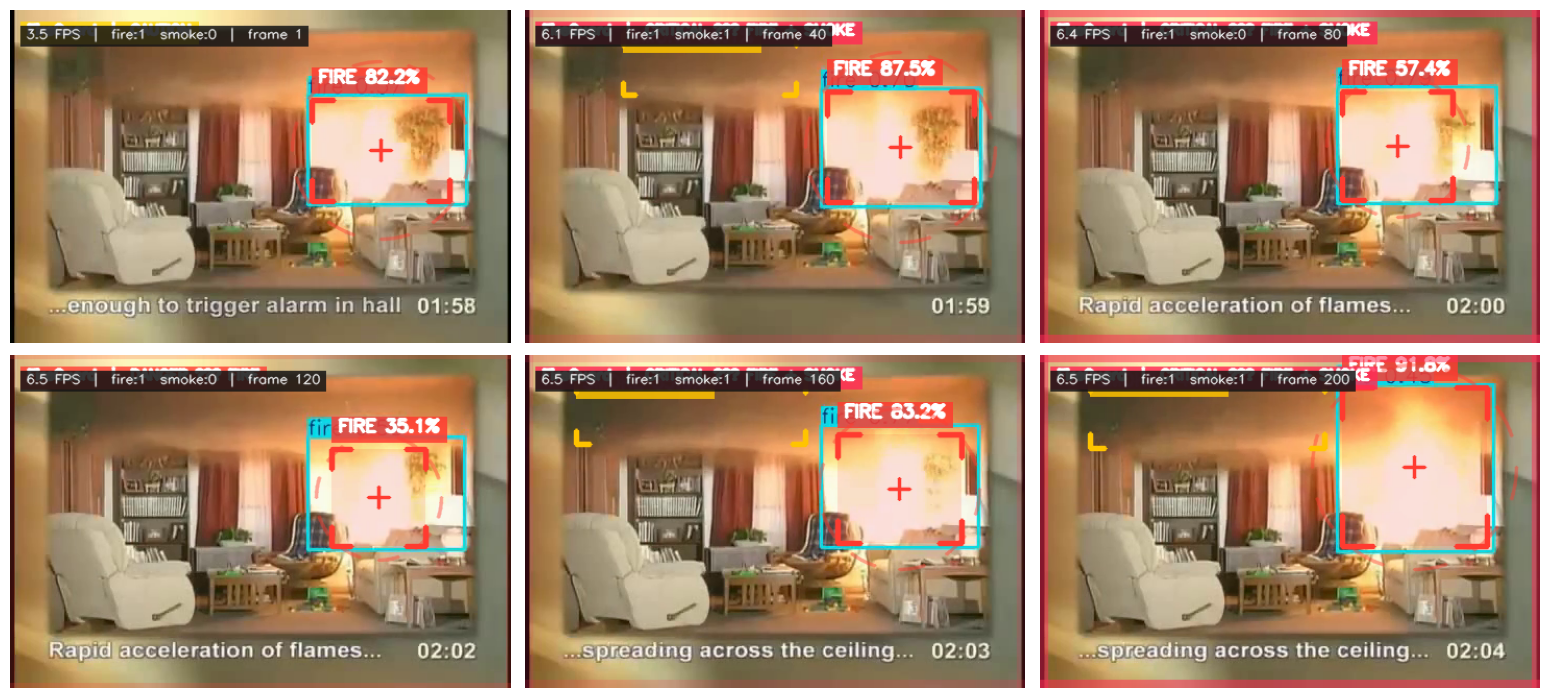

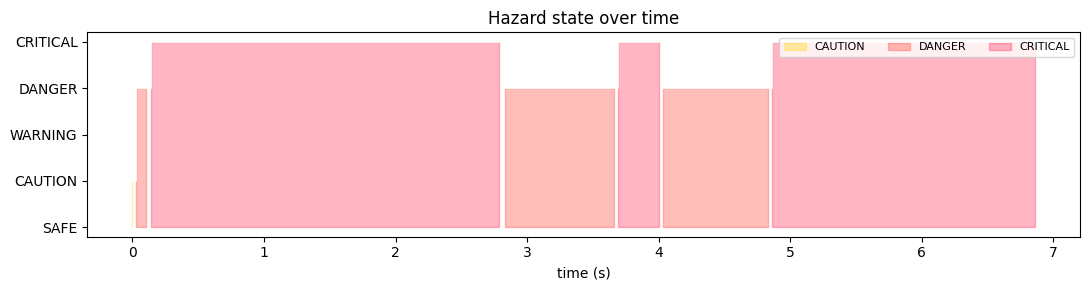

📄 events.csv


,frame,time_s,state,fire,smoke
0,1,0.00,CAUTION,1,0
1,2,0.03,DANGER,1,0
2,5,0.14,CRITICAL,1,1
3,83,2.83,DANGER,1,0
4,108,3.69,CRITICAL,2,1
5,118,4.03,DANGER,1,0
6,142,4.86,CRITICAL,1,1


In [10]:
import os

try:                                     # canonical Colab detection
    from google.colab import drive       # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    VIDEO_PATH = "/content/drive/MyDrive/fire_5.mp4"        # ← EDIT: your video in Drive
else:
    VIDEO_PATH = "fire_detection_result.mp4"                # ← EDIT: local path

# Demo convenience: analyse just the fire-heavy section of the bundled demo video.
# For YOUR video set both to 0 / None (whole video).
cfg = dict(CONFIG)
if VIDEO_PATH.endswith("fire_detection_result.mp4"):
    cfg["start_frame"], cfg["max_frames"] = 3400, 200
else:
    cfg["start_frame"], cfg["max_frames"] = 0, None

assert os.path.exists(VIDEO_PATH), f"Video not found: {VIDEO_PATH}"
model = load_model(CONFIG["model"])

summary, samples = process_video(model, cfg, VIDEO_PATH, out_name="fireguard_result.mp4")
show_samples(samples)
plot_timeline(summary)
show_events()


## 11 · Benchmark — all three models on the same section
Speed (CPU here — expect **10–30× faster on GPU**) and behavioural stability (fewer state changes = more temporally stable detections).


In [11]:
rows = []
for key in MODEL_REGISTRY:
    m = load_model(key)
    c = dict(cfg)
    c["display_samples"], c["snapshot"] = 0, False
    c["max_frames"] = min(c["max_frames"] or 120, 120)
    s, _ = process_video(m, c, VIDEO_PATH, out_name=f"bench_{key}.mp4", quiet=True)
    rows.append({
        "model": key,
        "params": MODEL_REGISTRY[key]["params"],
        "ms/frame": round(s["ms_per_inference"], 1),
        "FPS (inference)": round(1000 / s["ms_per_inference"], 1),
        "state changes": s["events"],
        "fire seen": s["fire_seen"],
        "smoke seen": s["smoke_seen"],
    })

bench = pd.DataFrame(rows)
os.makedirs(CONFIG["output_dir"], exist_ok=True)
bench.to_csv(os.path.join(CONFIG["output_dir"], "benchmark.csv"), index=False)
bench


✅ Loaded 'yolov8n.pt'  |  classes: ['smoke', 'fire']  |  device: cpu
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in

,model,params,ms/frame,FPS (inference),state changes,fire seen,smoke seen
0,yolov8n,3.0M,98.1,10.2,9,True,False
1,yolo11s,9.4M,140.6,7.1,16,True,False
2,yolo26s,9.9M,136.2,7.3,6,True,True


## 12 · Going further

- **Custom weights** — trained your own model? Just set `CONFIG["model"] = "path/to/best.pt"`; any Ultralytics detect model works, label spelling is auto-normalised.
- **Real-time camera** — replace the video path with `0` in OpenCV and stream through the same pipeline.
- **Deployment** — export to ONNX / TensorRT: `model.export(format="onnx")` for edge devices (Jetson, RPi5 + Hailo).
- **Alerting** — hook `events.csv` / snapshots into a Telegram bot, webhook or SIEM.
- **Roadmap** — RTSP multi-camera manager · object tracking IDs (how many distinct fires) · burned-area estimation · Gradio web demo.

---

*FireGuard is an assistive tool — always comply with local fire-safety regulations; do not use it as the sole life-safety system.*
